In [5]:
import pandas as pd
from collections import defaultdict

In [2]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [4]:
%%R

require('tidyverse')
require('DescTools')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: DescTools


In [6]:
# Load match data
df = pd.read_csv('atp_matches_2023.csv')
df = df.sort_values('tourney_date')

# Initialize Elo ratings
elo_ratings = defaultdict(lambda: 1500)

# Store Elo snapshot *before* each match
elo_snapshots = []

K = 30

def win_prob(rating_i, rating_j):
    return 1 / (1 + 10 ** ((rating_j - rating_i) / 400))

for _, match in df.iterrows():
    winner = match['winner_name']
    loser = match['loser_name']

    rating_winner = elo_ratings[winner]
    rating_loser = elo_ratings[loser]

    # Record pre-match Elo ratings
    elo_snapshots.append({
        'date': match['tourney_date'],
        'tournament': match['tourney_name'],
        'winner': winner,
        'loser': loser,
        'winner_elo_before': rating_winner,
        'loser_elo_before': rating_loser
    })

    # Calculate expected outcomes
    expected_win = win_prob(rating_winner, rating_loser)
    expected_loss = 1 - expected_win

    # Update ratings
    elo_ratings[winner] += K * (1 - expected_win)
    elo_ratings[loser] += K * (0 - expected_loss)

# Create DataFrame
elo_df = pd.DataFrame(elo_snapshots)
elo_df

,date,tournament,winner,loser,winner_elo_before,loser_elo_before
0,20230102,United Cup,Taylor Fritz,Matteo Berrettini,1500.000000,1500.000000
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000
2,20230102,Adelaide 1,Marcos Giron,Richard Gasquet,1500.000000,1500.000000
3,20230102,Adelaide 1,Mackenzie Mcdonald,Daniel Elahi Galan,1500.000000,1500.000000
4,20230102,Adelaide 1,Yoshihito Nishioka,Holger Rune,1500.000000,1500.000000
...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274
2982,20231127,NextGen Finals,Hamad Medjedovic,Abedallah Shelbayh,1570.877850,1447.949709
2983,20231127,NextGen Finals,Abedallah Shelbayh,Alex Michelsen,1438.046036,1489.435844
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672


In [7]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly assign winner to be Player A or B
winner_is_A = np.random.randint(0, 2, size=len(elo_df)) == 1

# Create transformed DataFrame
elo_transformed = pd.DataFrame({
    'date': elo_df['date'],
    'tournament': elo_df['tournament'],
    
    'player_A_name': np.where(winner_is_A, elo_df['winner'], elo_df['loser']),
    'player_B_name': np.where(winner_is_A, elo_df['loser'], elo_df['winner']),
    
    'player_A_elo_before': np.where(winner_is_A, elo_df['winner_elo_before'], elo_df['loser_elo_before']),
    'player_B_elo_before': np.where(winner_is_A, elo_df['loser_elo_before'], elo_df['winner_elo_before']),
    
    'player_A_win': winner_is_A.astype(int)
})
elo_transformed

,date,tournament,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win
0,20230102,United Cup,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1
2,20230102,Adelaide 1,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0
3,20230102,Adelaide 1,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0
4,20230102,Adelaide 1,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0
...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1
2982,20231127,NextGen Finals,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0
2983,20231127,NextGen Finals,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1


In [8]:
elo_transformed['elo_difference'] = elo_transformed['player_A_elo_before'] - elo_transformed ['player_B_elo_before']
elo_transformed

,date,tournament,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference
0,20230102,United Cup,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0,0.000000
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1,0.000000
2,20230102,Adelaide 1,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0,0.000000
3,20230102,Adelaide 1,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0,0.000000
4,20230102,Adelaide 1,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0,0.000000
...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1,83.006596
2982,20231127,NextGen Finals,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0,-122.928140
2983,20231127,NextGen Finals,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0,51.389809
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1,9.656621


## Ground truth


Attaching package: ‘flexplot’

The following object is masked from ‘package:ggplot2’:

    flip_data



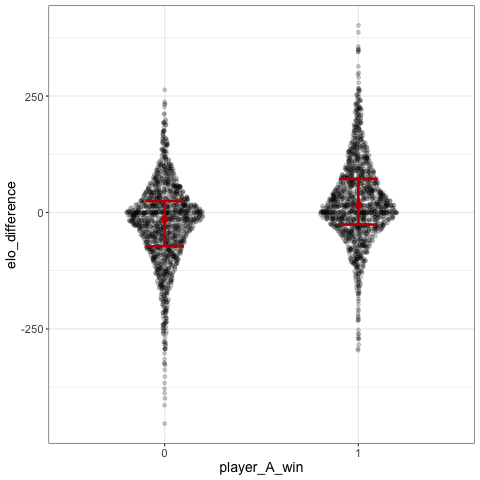

In [9]:
%%R -i elo_transformed

library(flexplot)
flexplot(elo_difference ~ player_A_win, data=elo_transformed)

In [10]:
%%R 

logistic <- glm(player_A_win ~ elo_difference, data=elo_transformed, family=binomial)
print(summary(logistic))
print(PseudoR2(logistic, which="McFadden"))



Call:
glm(formula = player_A_win ~ elo_difference, family = binomial, 
    data = elo_transformed)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.0239034  0.0380422  -0.628     0.53    
elo_difference  0.0065491  0.0004661  14.050   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4139.0  on 2985  degrees of freedom
Residual deviance: 3905.8  on 2984  degrees of freedom
AIC: 3909.8

Number of Fisher Scoring iterations: 4

  McFadden 
0.05634419 


In [11]:
%%R 

df <- elo_transformed %>% mutate(
    predict_proba_R = predict(logistic, type="response"),
    predict_R = ifelse(predict_proba_R > .5, 1,0)
) %>% arrange(elo_difference)

df %>% head()

         date         tournament           player_A_name  player_B_name
2085 20230807     Canada Masters             Ben Shelton Carlos Alcaraz
2147 20230814 Cincinnati Masters             Max Purcell Carlos Alcaraz
2346 20230828            Us Open Bernabe Zapata Miralles Novak Djokovic
2359 20230828            Us Open            Lloyd Harris Carlos Alcaraz
2365 20230828            Us Open        Alexandre Muller Novak Djokovic
2325 20230828            Us Open             Ben Shelton Novak Djokovic
     player_A_elo_before player_B_elo_before player_A_win elo_difference
2085            1410.849            1864.117            0      -453.2684
2147            1432.600            1846.424            0      -413.8242
2346            1458.761            1857.669            0      -398.9076
2359            1464.366            1852.335            0      -387.9684
2365            1481.946            1860.412            0      -378.4652
2325            1476.306            1842.450            0 

## Analyzing residuals

In [19]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange(desc(predict_proba_R))

head(df_filtered)

         date                   tournament      player_A_name   player_B_name
2860 20231030                Paris Masters     Carlos Alcaraz Roman Safiullin
2644 20231002             Shanghai Masters      Jannik Sinner     Ben Shelton
2411 20230915 Davis Cup WG1 R1: DEN vs BRA        Holger Rune Thiago Monteiro
1557 20230612                    Stuttgart Stefanos Tsitsipas Richard Gasquet
2094 20230807               Canada Masters Stefanos Tsitsipas    Gael Monfils
2005 20230731                   Washington    Grigor Dimitrov    Daniel Evans
     player_A_elo_before player_B_elo_before player_A_win elo_difference
2860            1837.876            1574.445            0       263.4314
2644            1784.218            1546.589            0       237.6282
2411            1664.950            1431.678            0       233.2716
1557            1696.759            1464.841            0       231.9176
2094            1699.698            1473.198            0       226.4997
2005            

In [20]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange((predict_proba_R))

head(df_filtered)

         date      tournament         player_A_name   player_B_name
1941 20230724         Hamburg       Daniel Altmaier   Andrey Rublev
1409 20230529   Roland Garros   Thiago Seyboth Wild Daniil Medvedev
1251 20230508    Rome Masters       Fabian Marozsan  Carlos Alcaraz
2105 20230807  Canada Masters            Tommy Paul  Carlos Alcaraz
1621 20230619           Halle Roberto Bautista Agut Daniil Medvedev
1528 20230612 s Hertogenbosch      Adrian Mannarino Daniil Medvedev
     player_A_elo_before player_B_elo_before player_A_win elo_difference
1941            1446.236            1742.111            1      -295.8749
1409            1500.000            1791.986            1      -291.9855
1251            1500.038            1783.473            1      -283.4351
2105            1599.816            1871.224            1      -271.4087
1621            1470.555            1741.957            1      -271.4018
1528            1497.795            1766.695            1      -268.9000
     predict_

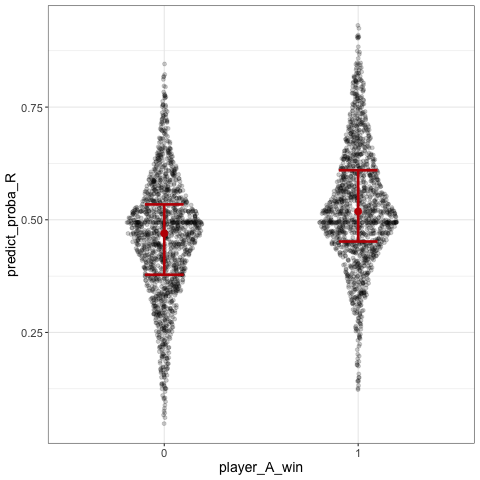

In [12]:
%%R 

flexplot(predict_proba_R ~ player_A_win, data=df, method='lm')

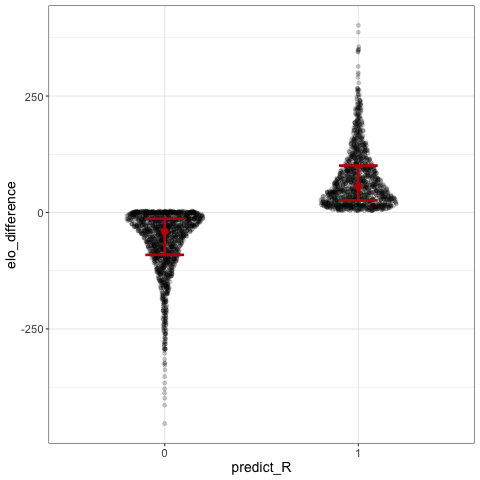

In [14]:
%%R 

flexplot(elo_difference ~ predict_R, data=df)

In [15]:
%%R 

# Create confusion matrix
conf_mat <- table(df$predict_R, df$player_A_win)
print(conf_mat) 

# Extract TP, FP, FN
TP <- conf_mat[2,2]
FP <- conf_mat[2,1]
FN <- conf_mat[1,2]
# Calculate Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
# Print
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")

   
      0   1
  0 980 653
  1 532 821
Precision: 0.6067997 
Recall: 0.5569878 
